In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score
from sklearn.ensemble import RandomForestClassifier
sns.set_style(style="whitegrid")

# Wstępna analiza zbioru

In [2]:
polish_companies_bankruptcy = fetch_ucirepo(id=365) 
X = polish_companies_bankruptcy.data.features 
y = polish_companies_bankruptcy.data.targets 

In [3]:
df = pd.concat([X, y], axis=1)
df

,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,class
0,1,0.200550,0.37951,0.396410,2.04720,32.3510,0.38825,0.249760,1.33050,1.13890,...,0.121960,0.397180,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.42770,0
1,1,0.209120,0.49988,0.472250,1.94470,14.7860,0.00000,0.258340,0.99601,1.69960,...,0.121300,0.420020,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.98700,0
2,1,0.248660,0.69592,0.267130,1.55480,-1.1523,0.00000,0.309060,0.43695,1.30900,...,0.241140,0.817740,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.20780,0
3,1,0.081483,0.30734,0.458790,2.49280,51.9520,0.14988,0.092704,1.86610,1.05710,...,0.054015,0.142070,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.54970,0
4,1,0.187320,0.61323,0.229600,1.40630,-7.3128,0.18732,0.187320,0.63070,1.15590,...,0.134850,0.484310,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.89800,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43400,5,0.012898,0.70621,0.038857,1.17220,-18.9070,0.00000,0.013981,0.41600,1.67680,...,0.020169,0.043904,1.01220,1.259400,13.4720,12.4320,49.117,7.4313,2.27990,1
43401,5,-0.578050,0.96702,-0.800850,0.16576,-67.3650,-0.57805,-0.578050,-0.40334,0.93979,...,-0.064073,1.482000,1.06410,-0.018084,110.7200,44.7590,81.220,4.4940,5.13050,1
43402,5,-0.179050,1.25530,-0.275990,0.74554,-120.4400,-0.17905,-0.154930,-0.26018,1.17490,...,0.148880,0.548240,0.85112,-0.522430,9.8526,3.4892,207.870,1.7559,9.95270,1
43403,5,-0.108860,0.74394,0.015449,1.08780,-17.0030,-0.10886,-0.109180,0.12531,0.84516,...,-0.183200,-1.167700,1.18320,6.092400,13.8860,6.0769,83.122,4.3911,0.95575,1


In [4]:
df.describe()

,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,class
count,43405.000000,43397.000000,43397.000000,43397.000000,43271.000000,4.331600e+04,43397.000000,43397.000000,43311.000000,43396.000000,...,4.327800e+04,43398.000000,4.332100e+04,43398.000000,4.125300e+04,43303.000000,4.327800e+04,43271.000000,42593.000000,43405.000000
mean,2.939753,0.035160,0.590212,0.114431,6.314702,-3.853480e+02,-0.056107,0.093478,12.640779,2.652166,...,-2.621959e+01,-0.010510,3.002644e+01,1.333288,4.481067e+02,17.033202,1.502521e+03,9.343074,72.796105,0.048174
std,1.283975,2.994109,5.842748,5.439429,295.434425,6.122797e+04,7.201326,5.713075,505.894281,62.932732,...,5.327862e+03,13.674072,5.334454e+03,122.104445,3.234518e+04,553.049406,1.393023e+05,124.177354,2369.744596,0.214137
min,1.000000,-463.890000,-430.870000,-479.960000,-0.403110,-1.190000e+07,-508.410000,-517.480000,-141.410000,-3.496000,...,-1.108300e+06,-1667.300000,-1.986900e+02,-327.970000,-1.244000e+01,-12.656000,-2.340000e+06,-1.543200,-10677.000000,0.000000
25%,2.000000,0.003429,0.268980,0.021521,1.049500,-4.908000e+01,0.000000,0.005776,0.430275,1.018500,...,9.348500e-03,0.014649,8.753200e-01,0.000000,5.545500e+00,4.510150,4.214400e+01,3.097650,2.176800,0.000000
50%,3.000000,0.049660,0.471900,0.196610,1.569800,-1.034500e+00,0.000000,0.059634,1.070400,1.195350,...,5.294300e-02,0.119670,9.509600e-01,0.006366,9.791700e+00,6.636300,7.132600e+01,5.087600,4.282500,0.000000
75%,4.000000,0.129580,0.688320,0.403390,2.787450,5.063425e+01,0.089446,0.150880,2.615700,2.062500,...,1.290975e-01,0.284605,9.926400e-01,0.236052,2.018100e+01,10.394500,1.172200e+02,8.598850,9.776200,0.000000
max,5.000000,94.280000,480.960000,28.336000,53433.000000,1.250100e+06,543.250000,649.230000,53432.000000,9742.300000,...,2.931500e+02,552.640000,1.108300e+06,23853.000000,4.818700e+06,108000.000000,2.501600e+07,23454.000000,294770.000000,1.000000


Zbiór zawiera $64$ cechy, kolumnę z klasą oraz rokiem, w którym dana obserwacja została zarejestrowana. Znajdują się w nim początkowo $43405$ obserwacji. Już na pierwszy rzut oka, możemy stwierdzić, że w zbiorze znajdują się wartości odstające, które mogą zaburzyć analizę. Przykładowo: cecha `A4` ma średnią około $6.31$, natomiast odchylenie standardowe wynosi $295$ (wartość maksymalna $53433$).

In [5]:
df['class'].value_counts(normalize=True) * 100

class
0    95.182583
1     4.817417
Name: proportion, dtype: float64

Zbiór jest niezbalansowany.

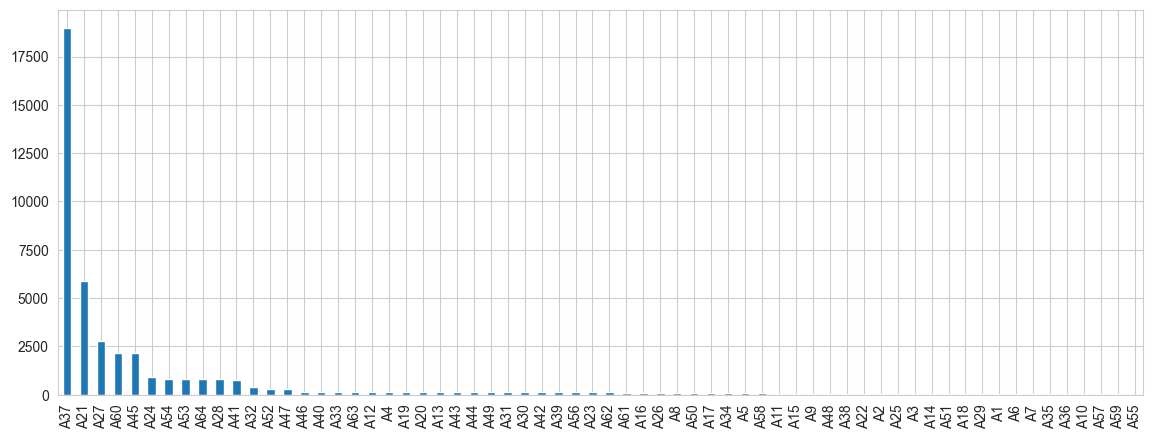

In [6]:
missing = df.isna().sum().sort_values(ascending=False)
plt.figure(figsize=(14, 5))
missing[missing > 0].plot(kind='bar')
plt.show()

In [7]:
(df.isnull().mean() * 100).sort_values(ascending=False)

A37      43.736897
A21      13.486925
A27       6.367930
A60       4.957954
A45       4.946435
           ...    
A57       0.016127
A59       0.016127
A55       0.002304
year      0.000000
class     0.000000
Length: 66, dtype: float64

A37 - (current assets - inventories) / long-term liabilities measures a company’s ability to pay short-term obligations or those due within one year

A21 - sales (n) / sales (n-1)

A27 - profit on operating activities / financial expenses

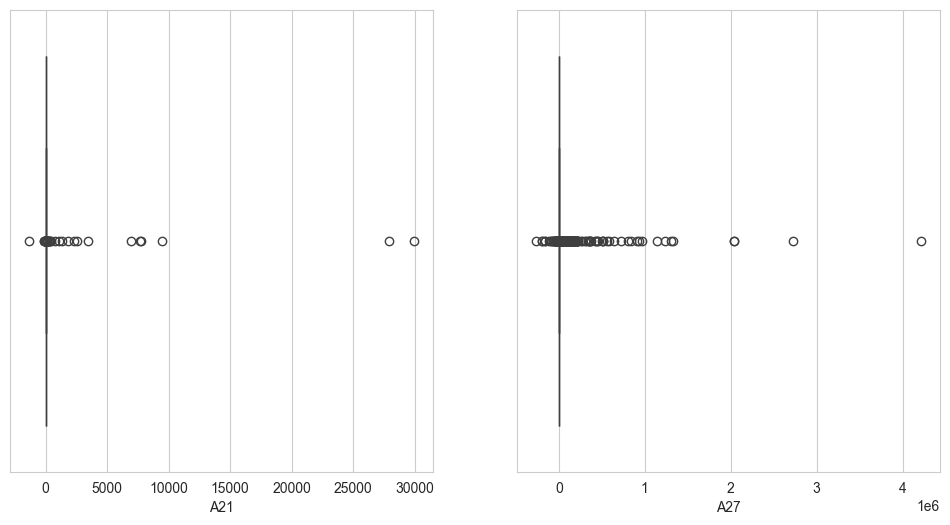

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(data=df, x='A21', ax=ax[0])
sns.boxplot(data=df, x='A27', ax=ax[1])
plt.show()

Widzimy, że są wartości odstające, być może powinniśmy przy zastępowaniu brakujących wartości zwrócić na to uwagę - zastąpić je medianą, bądź skorzystać z alogrytmu K najbliższych sąsiadów.

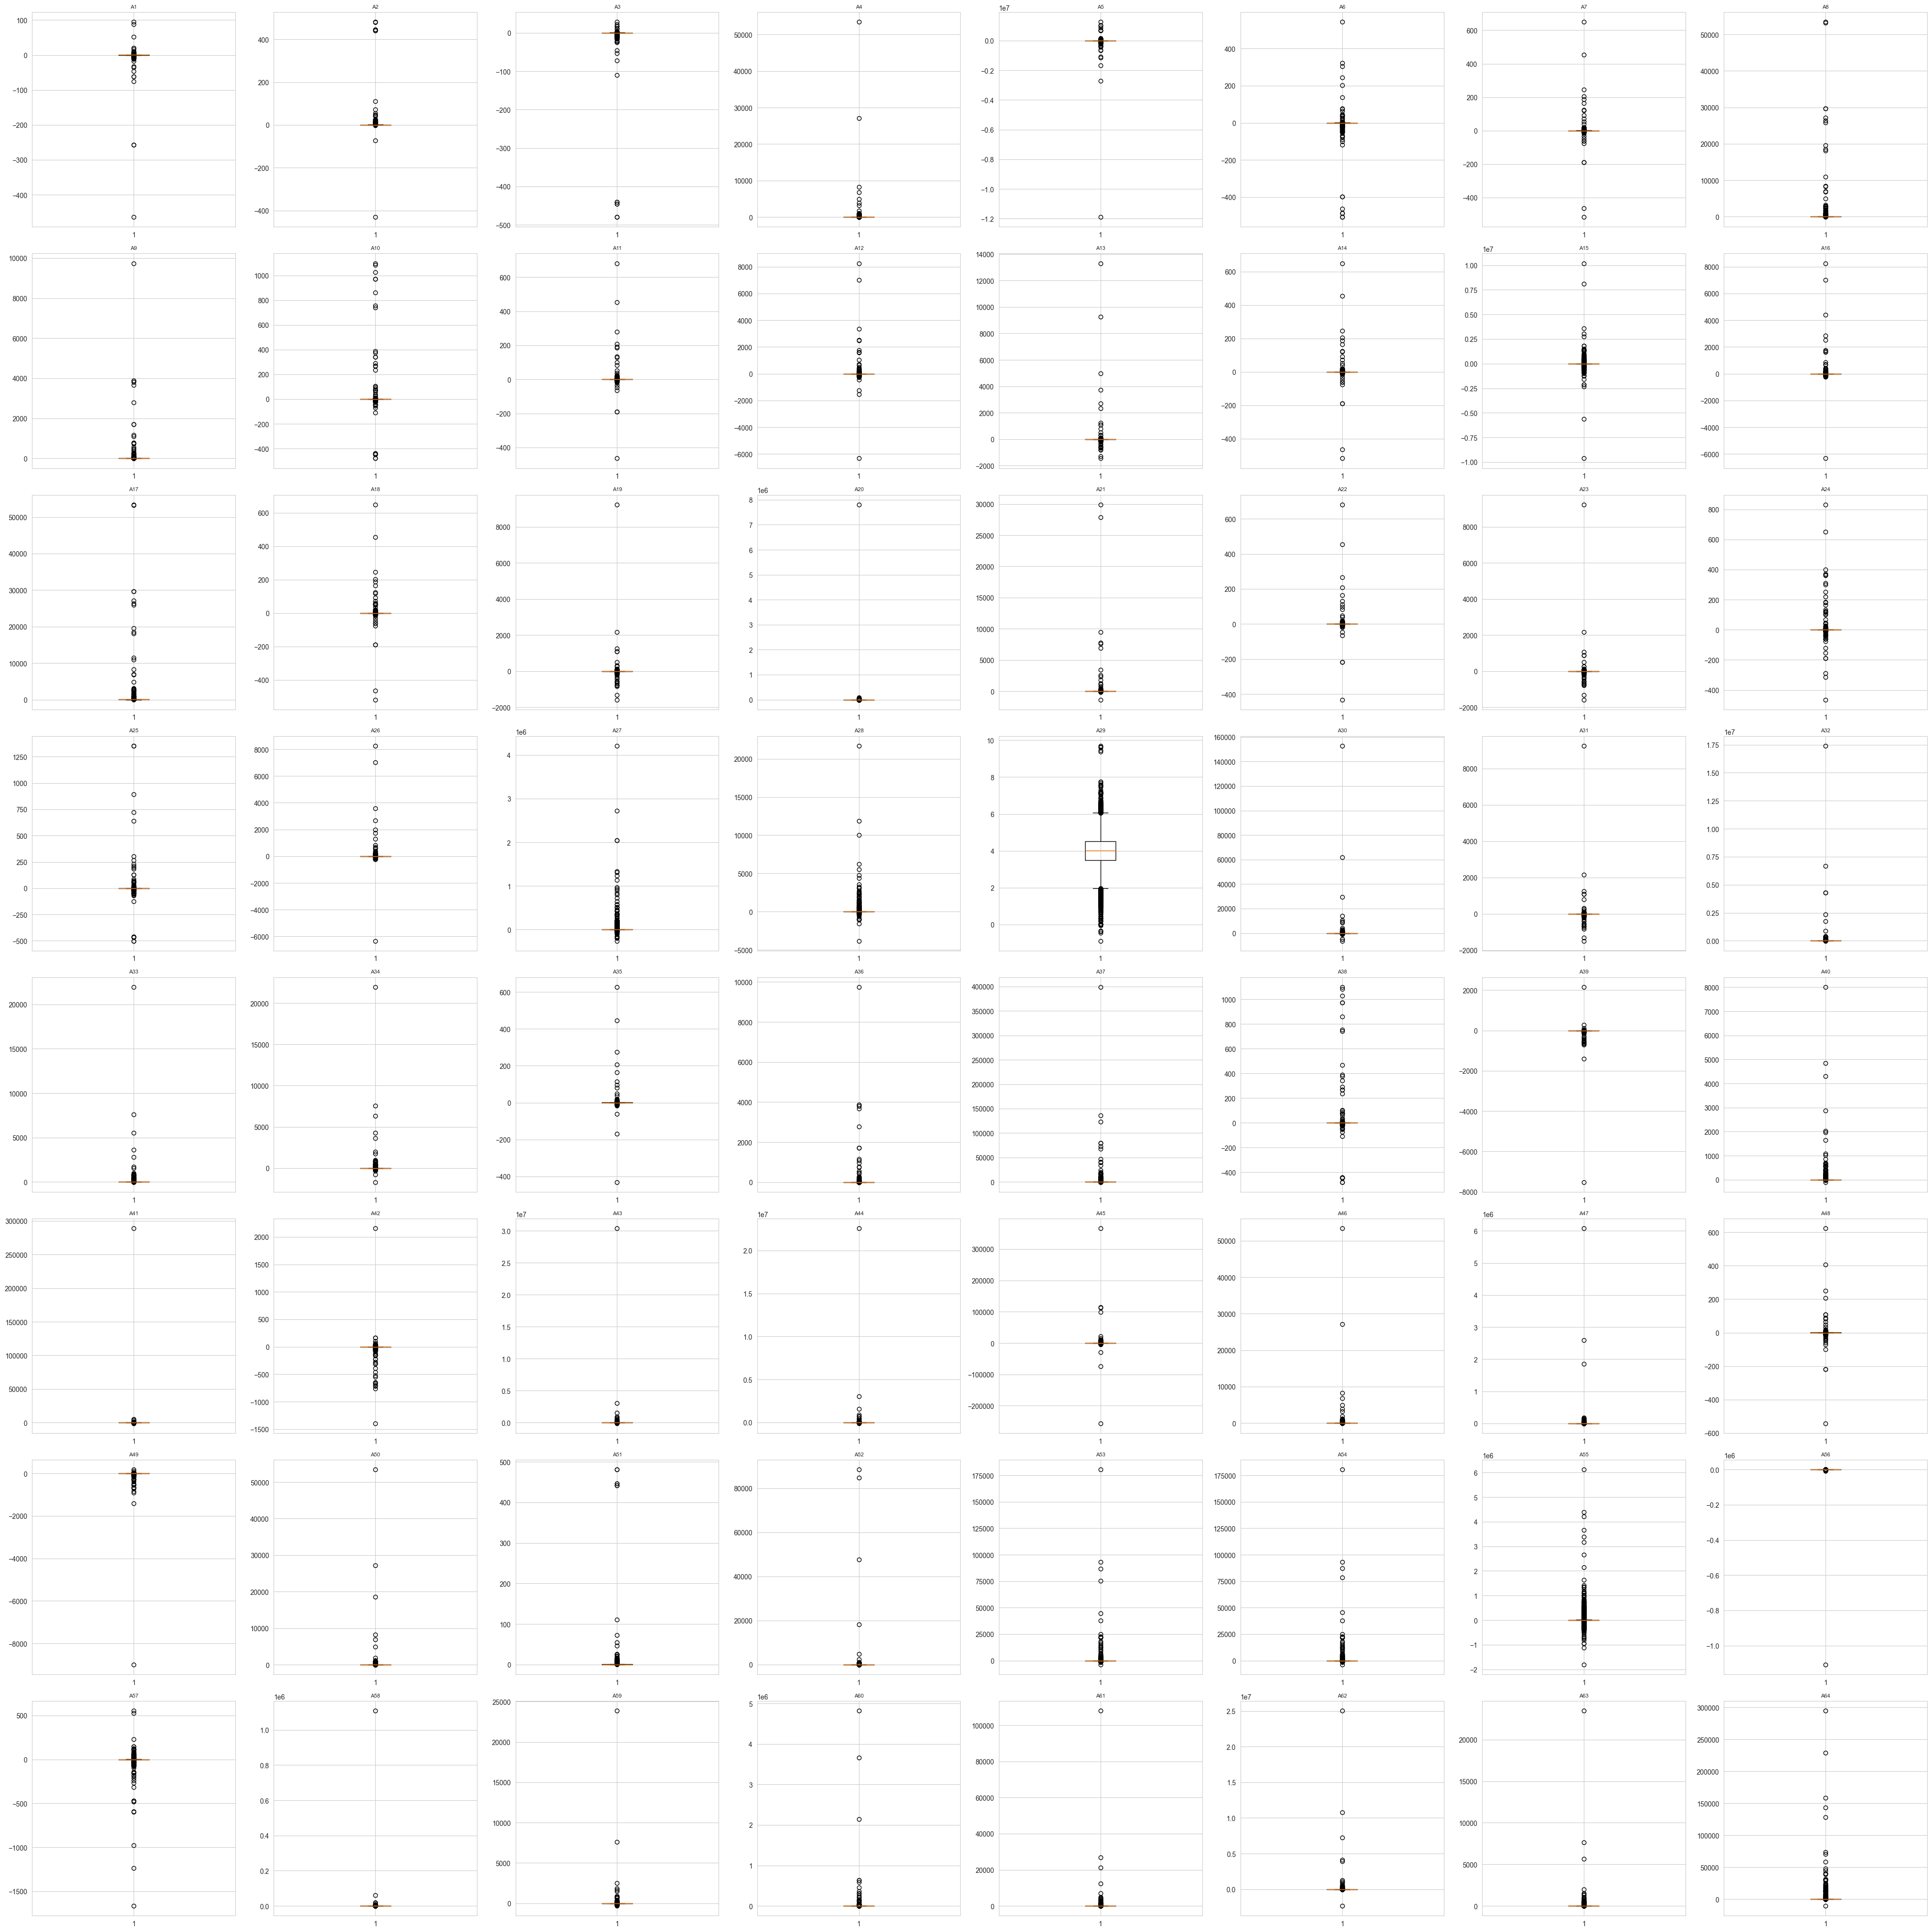

In [9]:
feature_cols = df.columns[1:-1]  # exclude "year" and "class"
fig, axs = plt.subplots(8, 8, figsize=(40, 40))
for i, col in enumerate(feature_cols):
    ax = axs[i // 8, i % 8]
    ax.boxplot(df[col].dropna())
    ax.set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

Widzimy, że w każdej cesze znajdują się `kropki`, które oznaczają outliersy. Są to wartości, które wychodzą poza $[Q_1 - 1.5 \cdot IQR, Q_3 + 1.5 \cdot IQR]$.

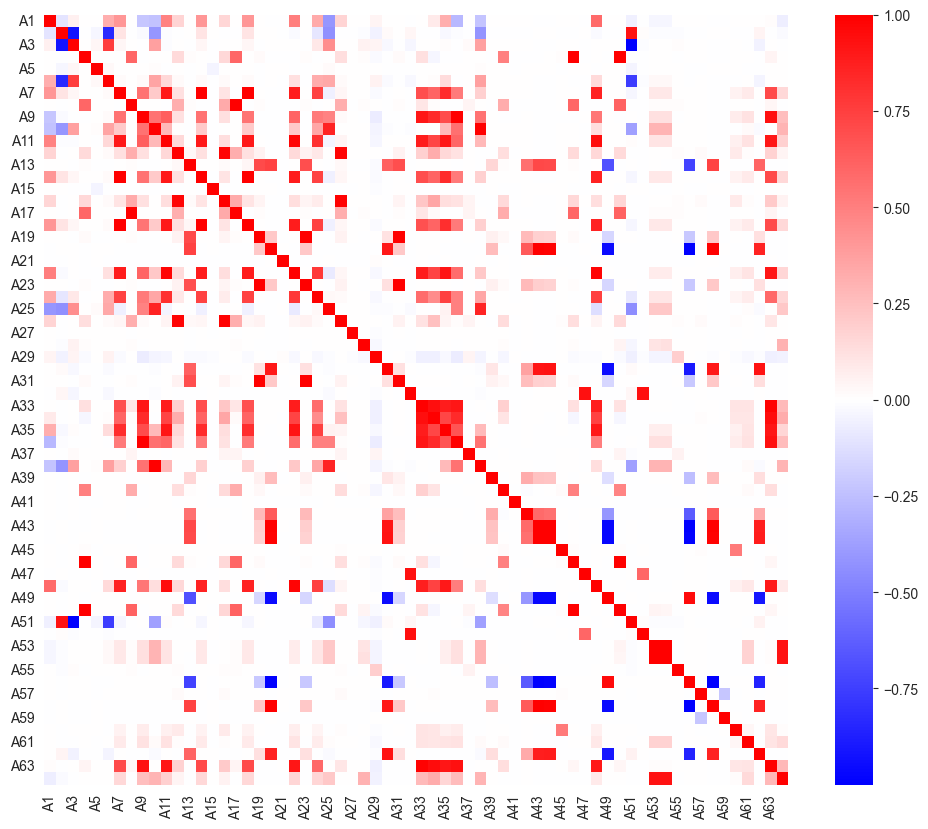

In [10]:
## correlation matrix
corr = df.drop(columns=["year","class"]).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="bwr", fmt=".2f")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
# plt.tight_layout()
# plt.title('Correlation Matrix')
plt.show()

Korelacja `A27` i `A21` z innymi kolumnami jest bardzo niska.

# Czyszczenie zbioru

## Imputacja brakujących wartości - KNN Imputer oraz usuwanie wartości odstających

In [11]:
df=df.drop(columns=['A37'])
df.drop_duplicates(inplace=True)

In [12]:
X = df.drop(columns='class')
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [13]:
imputer_KNN = KNNImputer(n_neighbors=5)
X_train_KNN = pd.DataFrame(imputer_KNN.fit_transform(X_train), columns=X_train.columns)
X_test_KNN = pd.DataFrame(imputer_KNN.transform(X_test), columns=X_test.columns)

In [14]:
Q1 = X_train_KNN.quantile(0.25)
Q3 = X_train_KNN.quantile(0.75)
IQR = Q3 - Q1

outliers_count = {}
for col in X_train_KNN.columns:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    outliers_count[col] = ((X_train_KNN[col] < lower) | (X_train_KNN[col] > upper)).sum()

outliers_count_X_train_KNN = pd.DataFrame.from_dict(outliers_count, orient='index', columns=["Outliers"])
print(outliers_count_X_train_KNN.sort_values("Outliers", ascending=False))

      Outliers
A6        8885
A27       7291
A45       6103
A55       5798
A15       5752
...        ...
A10        927
A3         925
A2         872
A29        670
year         0

[64 rows x 1 columns]


In [15]:
X_train_KNN = X_train_KNN.reset_index(drop=True)
y_train_KNN = y_train.reset_index(drop=True)

Q1_A6 = X_train_KNN['A6'].quantile(0.25)
Q3_A6 = X_train_KNN['A6'].quantile(0.75)
IQR_A6 = Q3_A6 - Q1_A6
lower_A6 = Q1_A6 - 1.5 * IQR_A6
upper_A6 = Q3_A6 + 1.5 * IQR_A6
mask_A6 = (X_train_KNN['A6'] >= lower_A6) & (X_train_KNN['A6'] <= upper_A6)
X_train_KNN_clean = X_train_KNN.loc[mask_A6]
y_train_KNN_clean = y_train_KNN.loc[mask_A6]

In [16]:
Q1_orig = X_train_KNN.quantile(0.25)
Q3_orig = X_train_KNN.quantile(0.75)
IQR_orig = Q3_orig - Q1_orig

outliers_orig = {}
for col in X_train_KNN.columns:
    lower_orig = Q1_orig[col] - 1.5 * IQR_orig[col]
    upper_orig = Q3_orig[col] + 1.5 * IQR_orig[col]
    outliers_orig[col] = ((X_train_KNN[col] < lower_orig) | (X_train_KNN[col] > upper_orig)).sum()

outliers_orig_df = pd.DataFrame.from_dict(outliers_orig, orient='index', columns=["Original Outliers"])

outliers_new = {}
for col in X_train_KNN.columns:
    lower_orig = Q1_orig[col] - 1.5 * IQR_orig[col]
    upper_orig = Q3_orig[col] + 1.5 * IQR_orig[col]
    outliers_new[col] = ((X_train_KNN_clean[col] < lower_orig) | (X_train_KNN_clean[col] > upper_orig)).sum()

outliers_new_df = pd.DataFrame.from_dict(outliers_new, orient='index', columns=["After A6 Removal"])

comparison_df = outliers_orig_df.join(outliers_new_df)
comparison_df["Dropped"] = comparison_df["Original Outliers"] - comparison_df["After A6 Removal"]

print(comparison_df.sort_values("Dropped", ascending=False))

      Original Outliers  After A6 Removal  Dropped
A6                 8885                 0     8885
A55                5798              3402     2396
A45                6103              3933     2170
A23                4488              2472     2016
A19                4090              2237     1853
...                 ...               ...      ...
A9                 2375              1907      468
A47                2131              1670      461
A34                2582              2169      413
A29                 670               325      345
year                  0                 0        0

[64 rows x 3 columns]


## Imputacja brakujących wartości - mediana oraz usuwanie wartości odstających

In [17]:
imputer_median = SimpleImputer(strategy='median')
X_train_median = pd.DataFrame(imputer_median.fit_transform(X_train), columns=X_train.columns)
X_test_median = pd.DataFrame(imputer_median.transform(X_test), columns=X_test.columns)

In [18]:
outliers_count = {}
for col in X_train_median.columns:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    outliers_count[col] = ((X_train_median[col] < lower) | (X_train_median[col] > upper)).sum()

outliers_count_X_train_median = pd.DataFrame.from_dict(
    outliers_count, orient='index', columns=["Outliers"]
)
print(outliers_count_X_train_median.sort_values("Outliers", ascending=False))

      Outliers
A6        8883
A27       6291
A55       5797
A15       5748
A41       5443
...        ...
A10        926
A3         923
A2         872
A29        670
year         0

[64 rows x 1 columns]


In [19]:
X_train_median = X_train_median.reset_index(drop=True)
y_train_median = y_train.reset_index(drop=True)
Q1_A6 = X_train_median['A6'].quantile(0.25)
Q3_A6 = X_train_median['A6'].quantile(0.75)
IQR_A6 = Q3_A6 - Q1_A6
lower_A6 = Q1_A6 - 1.5 * IQR_A6
upper_A6 = Q3_A6 + 1.5 * IQR_A6
mask_A6 = (X_train_median['A6'] >= lower_A6) & (X_train_median['A6'] <= upper_A6)

X_train_median_clean = X_train_median.loc[mask_A6]
y_train_median_clean = y_train_median.loc[mask_A6]

In [20]:
Q1_orig = X_train_median.quantile(0.25)
Q3_orig = X_train_median.quantile(0.75)
IQR_orig = Q3_orig - Q1_orig

outliers_orig = {}
for col in X_train_median.columns:
    lower_orig = Q1_orig[col] - 1.5 * IQR_orig[col]
    upper_orig = Q3_orig[col] + 1.5 * IQR_orig[col]
    outliers_orig[col] = ((X_train_median[col] < lower_orig) | (X_train_median[col] > upper_orig)).sum()

outliers_orig_df = pd.DataFrame.from_dict(outliers_orig, orient='index', columns=["Original Outliers"])

outliers_new = {}
for col in X_train_median.columns:
    lower_orig = Q1_orig[col] - 1.5 * IQR_orig[col]
    upper_orig = Q3_orig[col] + 1.5 * IQR_orig[col]
    outliers_new[col] = ((X_train_median_clean[col] < lower_orig) | (X_train_median_clean[col] > upper_orig)).sum()

outliers_new_df = pd.DataFrame.from_dict(outliers_new, orient='index', columns=["After A6 Removal"])
comparison_df = outliers_orig_df.join(outliers_new_df)
comparison_df["Dropped"] = comparison_df["Original Outliers"] - comparison_df["After A6 Removal"]

print(comparison_df.sort_values("Dropped", ascending=False))

      Original Outliers  After A6 Removal  Dropped
A6                 8883                 0     8883
A55                5797              3401     2396
A45                5865              3758     2107
A23                4453              2460     1993
A19                4058              2227     1831
...                 ...               ...      ...
A9                 2375              1907      468
A47                2114              1653      461
A34                2562              2158      404
A29                 670               325      345
year                  0                 0        0

[64 rows x 3 columns]


Wyniki są bardzo podobne w obu przypadkach.

## Skalowanie danych

In [21]:
scaler = StandardScaler()
X_train_scaled_KNN = pd.DataFrame(scaler.fit_transform(X_train_KNN_clean), columns=X_train_KNN_clean.columns)
X_test_scaled_KNN = pd.DataFrame(scaler.transform(X_test_KNN), columns=X_test_KNN.columns)

X_train_scaled_median = pd.DataFrame(scaler.fit_transform(X_train_median_clean), columns=X_train_median_clean.columns)
X_test_scaled_median = pd.DataFrame(scaler.transform(X_test_median), columns=X_test_median.columns)

## PCA

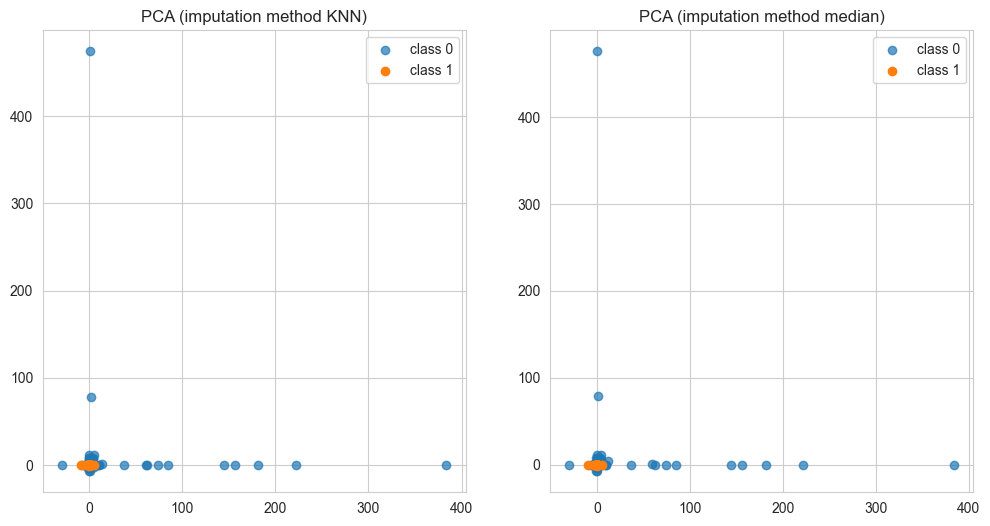

In [ ]:
pca = PCA(n_components=2)
X_train_pca_knn = pca.fit_transform(X_train_scaled_KNN)
X_test_pca_knn = pca.transform(X_test_scaled_KNN)
X_train_pca_median = pca.fit_transform(X_train_scaled_median)
X_test_pca_median = pca.transform(X_test_scaled_median)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
mask0_knn = (y_train_KNN_clean == 0)
mask1_knn = (y_train_KNN_clean == 1)
ax[0].scatter(X_train_pca_knn[mask0_knn, 0], X_train_pca_knn[mask0_knn, 1],
              color='C0', label='class 0', alpha=0.7)
ax[0].scatter(X_train_pca_knn[mask1_knn, 0], X_train_pca_knn[mask1_knn, 1],
              color='C1', label='class 1')
ax[0].set_title("PCA (imputation method KNN)")
ax[0].legend()

mask0_med = (y_train_median_clean == 0)
mask1_med = (y_train_median_clean == 1)
ax[1].scatter(X_train_pca_median[mask0_med, 0], X_train_pca_median[mask0_med, 1],
              color='C0', label='class 0', alpha=0.7)
ax[1].scatter(X_train_pca_median[mask1_med, 0], X_train_pca_median[mask1_med, 1],
              color='C1', label='class 1')
ax[1].set_title("PCA (imputation method median)")
ax[1].legend()
plt.show()

## t-SNE

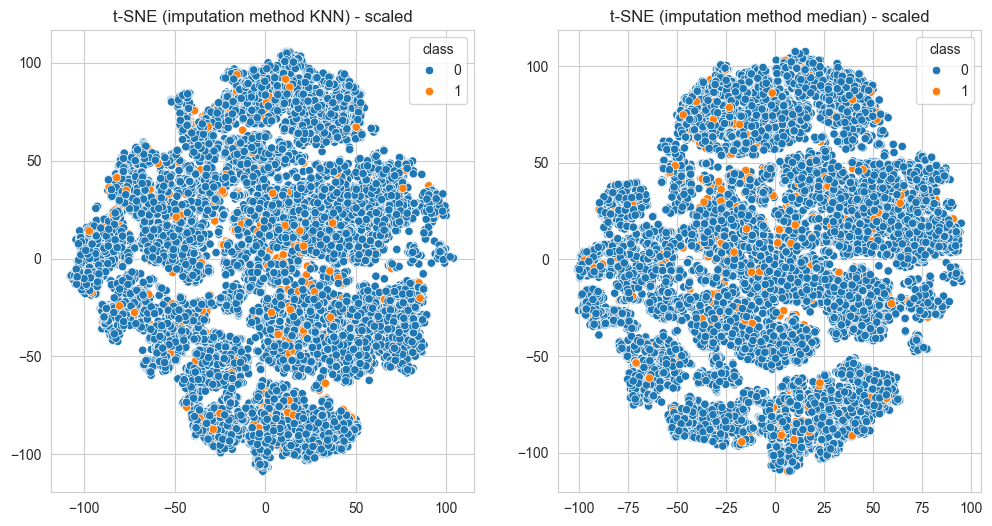

In [ ]:
tsne = TSNE(n_components=2)
X_train_tsne_knn = tsne.fit_transform(X_train_scaled_KNN)
X_train_tsne_median = tsne.fit_transform(X_train_scaled_median)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.scatterplot(x=X_train_tsne_knn[:, 0], y=X_train_tsne_knn[:, 1], hue=y_train_KNN_clean, ax=ax[0])
ax[0].set_title("t-SNE (imputation method KNN) - scaled")
sns.scatterplot(x=X_train_tsne_median[:, 0], y=X_train_tsne_median[:, 1], hue=y_train_median_clean, ax=ax[1])
ax[1].set_title("t-SNE (imputation method median) - scaled")
plt.show()

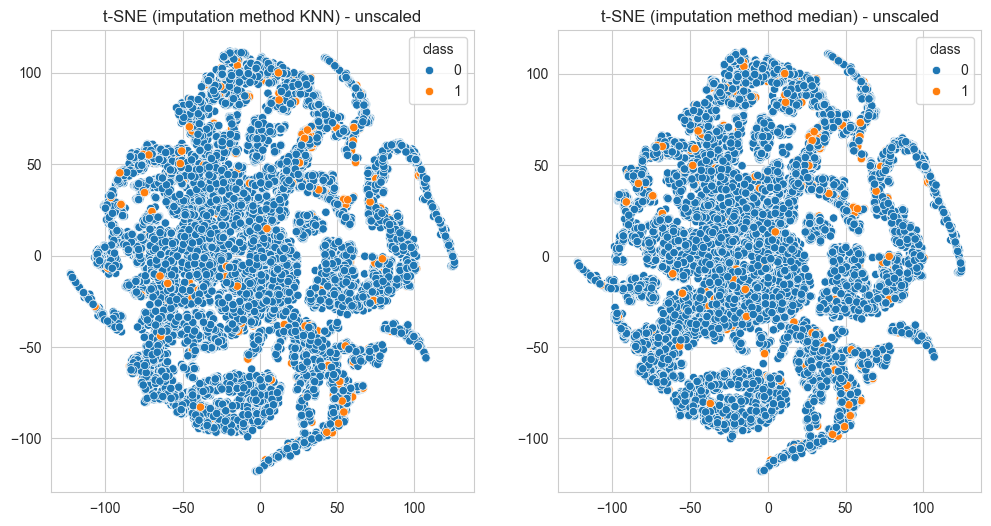

In [ ]:
tsne = TSNE(n_components=2)
X_train_tsne_knn_unscaled = tsne.fit_transform(X_train_KNN_clean)
X_train_tsne_median_unscaled = tsne.fit_transform(X_train_median_clean)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.scatterplot(x=X_train_tsne_knn_unscaled[:, 0], y=X_train_tsne_knn_unscaled[:, 1], hue=y_train_KNN_clean, ax=ax[0])
ax[0].set_title("t-SNE (imputation method KNN) - unscaled")
sns.scatterplot(x=X_train_tsne_median_unscaled[:, 0], y=X_train_tsne_median_unscaled[:, 1], hue=y_train_median_clean, ax=ax[1])
ax[1].set_title("t-SNE (imputation method median) - unscaled")
plt.show()

## Redukcja wymiarów - PCA

In [34]:
pca = PCA(0.95)
X_train_pca_knn = pca.fit_transform(X_train_scaled_KNN)
X_test_pca_knn = pca.transform(X_test_scaled_KNN)
print(f"Number of components selected: {pca.n_components_}")
X_train_pca_median = pca.fit_transform(X_train_scaled_median)
X_test_pca_median = pca.transform(X_test_scaled_median)
print(f"Number of components selected: {pca.n_components_}")

Number of components selected: 30
Number of components selected: 30


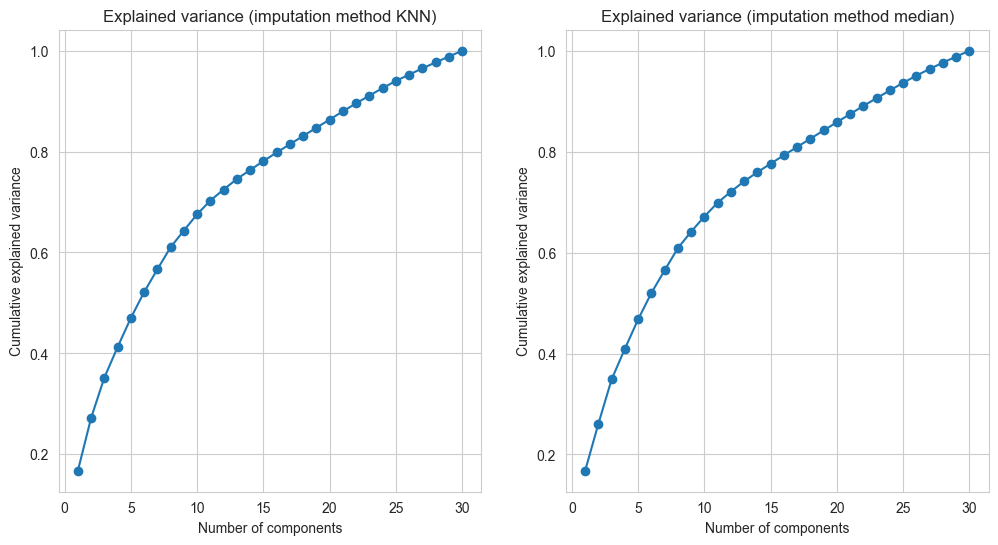

In [23]:
X_train_final_knn = pd.DataFrame(X_train_pca_knn)
X_test_final_knn = pd.DataFrame(X_test_pca_knn)

X_train_final_median = pd.DataFrame(X_train_pca_median)
X_test_final_median = pd.DataFrame(X_test_pca_median)

cov_matrix_knn = np.cov(X_train_final_knn.T)
eigenvalues_knn, eigenvectors_knn = np.linalg.eig(cov_matrix_knn)
tot=sum(eigenvalues_knn)
var_exp_knn = [(i / tot) for i in sorted(eigenvalues_knn, reverse=True)]
cum_var_exp_knn = np.cumsum(var_exp_knn)

cov_matrix_median = np.cov(X_train_final_median.T)
eigenvalues_median, eigenvectors_median = np.linalg.eig(cov_matrix_median)
tot=sum(eigenvalues_median)
var_exp_median = [(i / tot) for i in sorted(eigenvalues_median, reverse=True)]
cum_var_exp_median = np.cumsum(var_exp_median)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(range(1, len(var_exp_knn) + 1), cum_var_exp_knn, marker='o')
ax[0].set_title("Explained variance (imputation method KNN)")
ax[0].set_xlabel("Number of components")
ax[0].set_ylabel("Cumulative explained variance")
ax[1].plot(range(1, len(var_exp_median) + 1), cum_var_exp_median, marker='o')
ax[1].set_title("Explained variance (imputation method median)")
ax[1].set_xlabel("Number of components")
ax[1].set_ylabel("Cumulative explained variance")
plt.show()

# Modelowanie

In [ ]:
gbc = GradientBoostingClassifier()

gbc.fit(X_train_final_knn, y_train_KNN_clean)
y_pred_knn = gbc.predict(X_test_final_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
print(f"Accuracy (GradientBoostingClassifier, imputation method KNN): {accuracy_knn:.2f}")
print(f"Precison (GradientBoostingClassifier, imputation method KNN): {precision_knn:.2f}")
print(f"Recall (GradientBoostingClassifier, imputation method KNN): {recall_knn:.2f}")

Accuracy (GradientBoostingClassifier, imputation method KNN): 0.93
Precison (GradientBoostingClassifier, imputation method KNN): 0.12
Recall (GradientBoostingClassifier, imputation method KNN): 0.06


In [25]:
gbc.fit(X_train_final_median, y_train_median_clean)
y_pred_median = gbc.predict(X_test_final_median)
accuracy_median = accuracy_score(y_test, y_pred_median)
precision_median = precision_score(y_test, y_pred_median)
recall_median = recall_score(y_test, y_pred_median)
print(f"Accuracy (GradientBoostingClassifier, imputation method median): {accuracy_median:.2f}")
print(f"Precison (GradientBoostingClassifier, imputation method median): {precision_median:.2f}")
print(f"Recall (GradientBoostingClassifier, imputation method median): {recall_median:.2f}")

Accuracy (GradientBoostingClassifier, imputation method median): 0.92
Precison (GradientBoostingClassifier, imputation method median): 0.16
Recall (GradientBoostingClassifier, imputation method median): 0.13


In [26]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_final_knn, y_train_KNN_clean)
y_pred_knn_rf = rf.predict(X_test_final_knn)
accuracy_knn_rf = accuracy_score(y_test, y_pred_knn_rf)
precision_knn_rf = precision_score(y_test, y_pred_knn_rf)
recall_knn_rf = recall_score(y_test, y_pred_knn_rf)
print(f"Accuracy (Random Forest, imputation method KNN): {accuracy_knn_rf:.2f}")
print(f"Precison (Random Forest, imputation method KNN): {precision_knn_rf:.2f}")
print(f"Recall (Random Forest, imputation method KNN): {recall_knn_rf:.2f}")

Accuracy (Random Forest, imputation method KNN): 0.95
Precison (Random Forest, imputation method KNN): 0.22
Recall (Random Forest, imputation method KNN): 0.02


In [27]:
rf.fit(X_train_final_median, y_train_median_clean)
y_pred_median_rf = rf.predict(X_test_final_median)
accuracy_median_rf = accuracy_score(y_test, y_pred_median_rf)
precision_median_rf = precision_score(y_test, y_pred_median_rf)
recall_median_rf = recall_score(y_test, y_pred_median_rf)
print(f"Accuracy (Random Forest, imputation method median): {accuracy_median_rf:.2f}")
print(f"Precison (Random Forest, imputation method median): {precision_median_rf:.2f}")
print(f"Recall (Random Forest, imputation method median): {recall_median_rf:.2f}")

Accuracy (Random Forest, imputation method median): 0.95
Precison (Random Forest, imputation method median): 0.34
Recall (Random Forest, imputation method median): 0.03


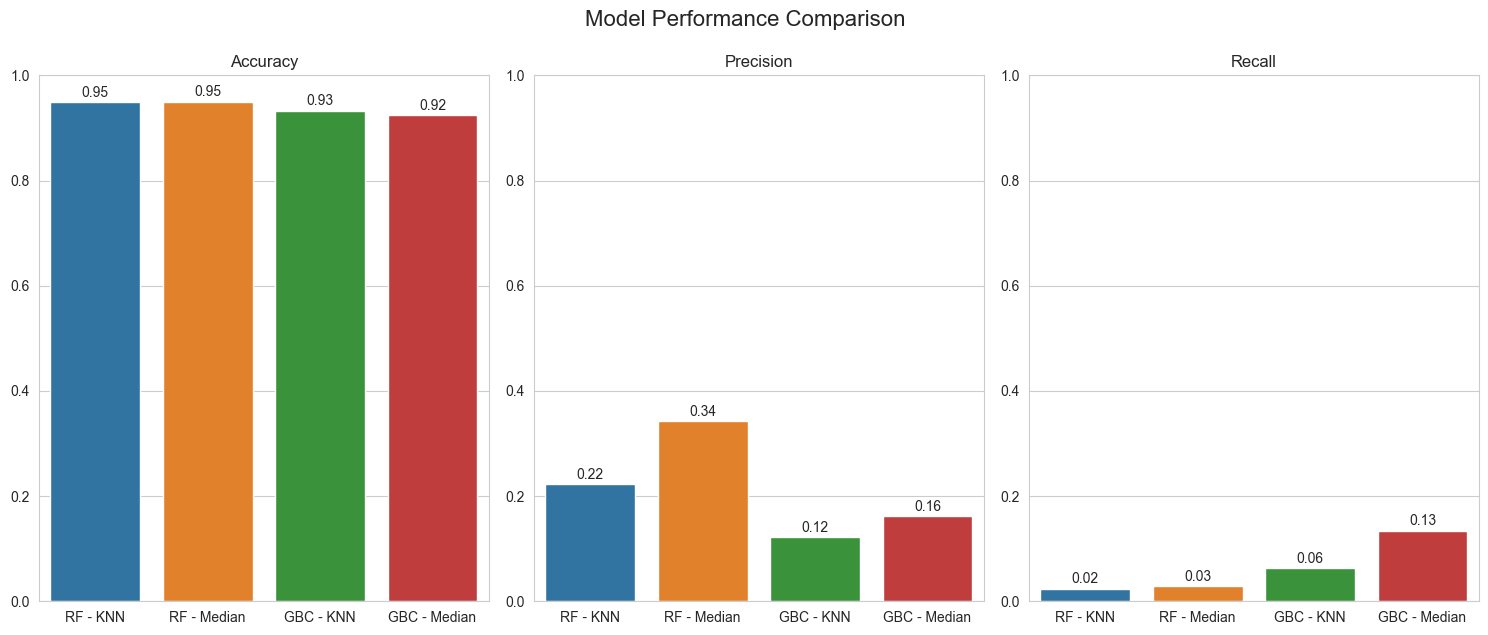

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(15, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
model_names = ["RF - KNN", "RF - Median", "GBC - KNN", "GBC - Median"]
metrics_values = [
    [accuracy_knn_rf, accuracy_median_rf, accuracy_knn, accuracy_median],
    [precision_knn_rf, precision_median_rf, precision_knn, precision_median],
    [recall_knn_rf, recall_median_rf, recall_knn, recall_median]
]
metric_titles = ["Accuracy", "Precision", "Recall"]

for i, (values, title) in enumerate(zip(metrics_values, metric_titles)):
    sns.barplot(x=model_names, y=values, ax=ax[i], palette=colors, hue=model_names)
    ax[i].set_title(title)
    #ax[i].set_ylim(0, max(max(values) * 1.1, 0.12 if title != "Accuracy" else 1.0))
    ax[i].set_xlabel("")
    
    for j, v in enumerate(values):
        ax[i].text(j, v + 0.01, f"{v:.2f}", ha='center')

ax[0].set_ylim(0, 1)
ax[1].set_ylim(0, 1)
ax[2].set_ylim(0, 1)
plt.tight_layout()
plt.suptitle("Model Performance Comparison", y=1.05, fontsize=16)
plt.show()

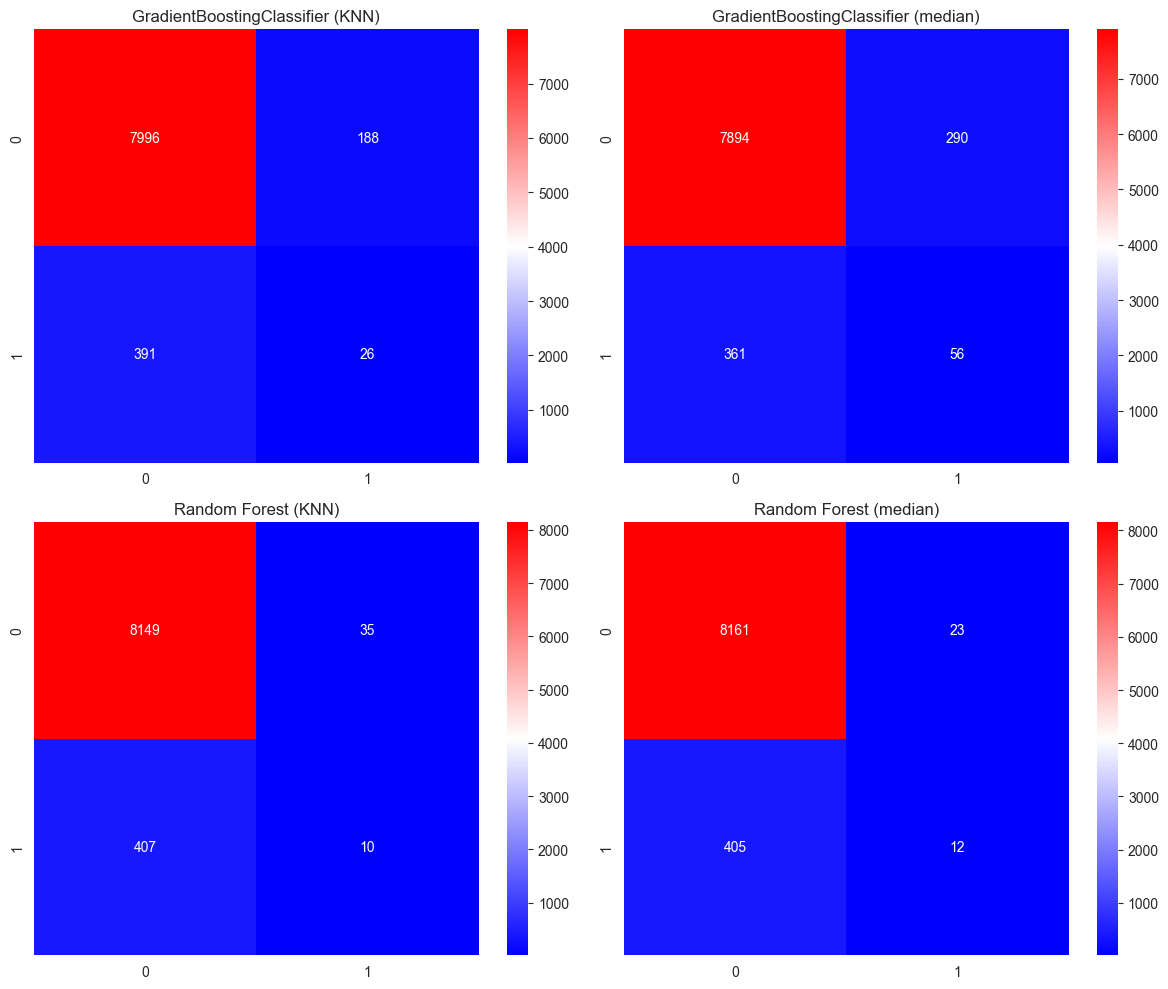

In [29]:
cm = confusion_matrix(y_test, y_pred_knn)
cm1 = confusion_matrix(y_test, y_pred_median)
cm2 = confusion_matrix(y_test, y_pred_knn_rf)
cm3 = confusion_matrix(y_test, y_pred_median_rf)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="bwr", ax=ax[0, 0])
ax[0, 0].set_title("GradientBoostingClassifier (KNN)")
sns.heatmap(cm1, annot=True, fmt="d", cmap="bwr", ax=ax[0, 1])
ax[0, 1].set_title("GradientBoostingClassifier (median)")
sns.heatmap(cm2, annot=True, fmt="d", cmap="bwr", ax=ax[1, 0])
ax[1, 0].set_title("Random Forest (KNN)")
sns.heatmap(cm3, annot=True, fmt="d", cmap="bwr", ax=ax[1, 1])
ax[1, 1].set_title("Random Forest (median)")
plt.tight_layout()
plt.show()

# A co by było gdyby?

## Train-test split na zbiorze z outlierami, nieprzeskalowane - PCA

c:\Users\jakub\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


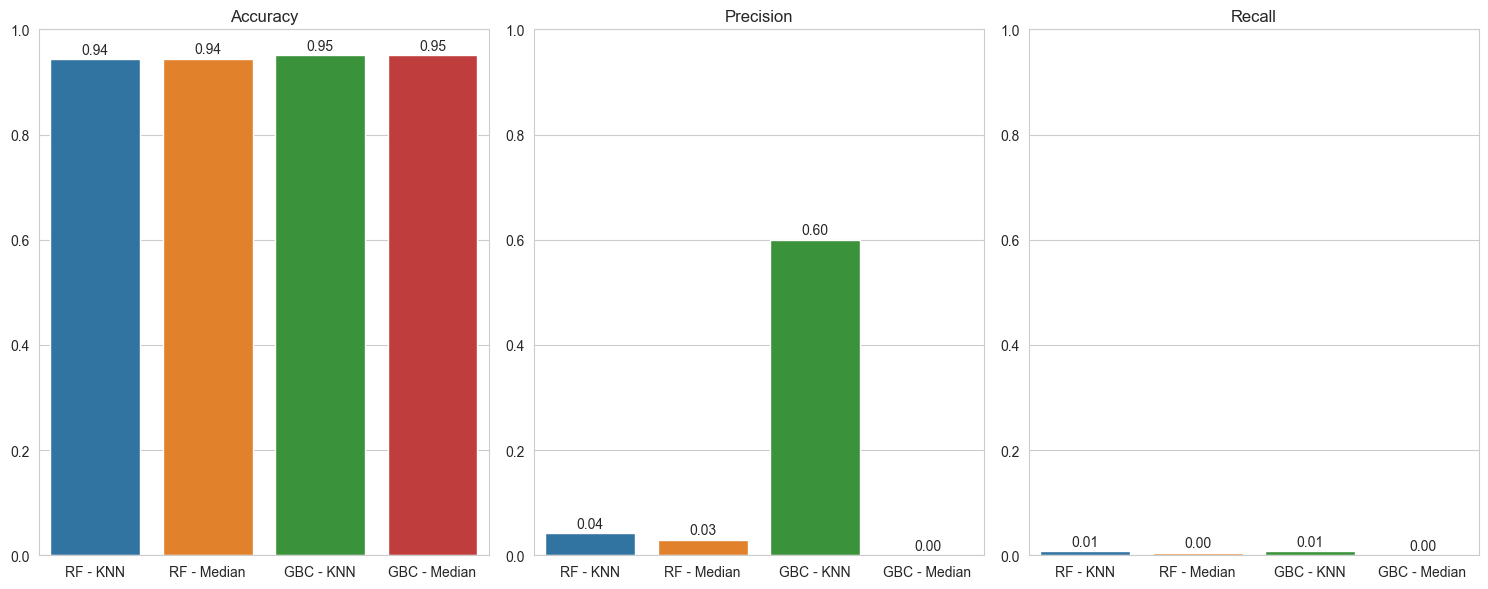

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train_KNN = pd.DataFrame(imputer_KNN.fit_transform(X_train), columns=X_train.columns)
X_test_KNN = pd.DataFrame(imputer_KNN.transform(X_test), columns=X_test.columns)
X_train_median = pd.DataFrame(imputer_median.fit_transform(X_train), columns=X_train.columns)
X_test_median = pd.DataFrame(imputer_median.transform(X_test), columns=X_test.columns)
X_train_pca_knn = pca.fit_transform(X_train_KNN)
X_test_pca_knn = pca.transform(X_test_KNN)
X_train_pca_median = pca.fit_transform(X_train_median)
X_test_pca_median = pca.transform(X_test_median)
X_train_final_knn = pd.DataFrame(X_train_pca_knn)
X_test_final_knn = pd.DataFrame(X_test_pca_knn)
X_train_final_median = pd.DataFrame(X_train_pca_median)
X_test_final_median = pd.DataFrame(X_test_pca_median)

gbc.fit(X_train_final_knn, y_train)
y_pred_knn = gbc.predict(X_test_final_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
#print(f"Accuracy (GradientBoostingClassifier, imputation method KNN, no scaling, PCA): {accuracy_knn:.2f}")
gbc.fit(X_train_final_median, y_train)
y_pred_median = gbc.predict(X_test_final_median)
accuracy_median = accuracy_score(y_test, y_pred_median)
precision_median = precision_score(y_test, y_pred_median)
recall_median = recall_score(y_test, y_pred_median)

#print(f"Accuracy (GradientBoostingClassifier, imputation method median, no scaling, PCA): {accuracy_median:.2f}")
rf.fit(X_train_final_knn, y_train)
y_pred_knn_rf = rf.predict(X_test_final_knn)
accuracy_knn_rf = accuracy_score(y_test, y_pred_knn_rf)
precision_knn_rf = precision_score(y_test, y_pred_knn_rf)
recall_knn_rf = recall_score(y_test, y_pred_knn_rf)
#print(f"Accuracy (Random Forest, imputation method KNN, no scaling, PCA): {accuracy_knn_rf:.2f}")
rf.fit(X_train_final_median, y_train)
y_pred_median_rf = rf.predict(X_test_final_median)
accuracy_median_rf = accuracy_score(y_test, y_pred_median_rf)
precision_median_rf = precision_score(y_test, y_pred_median_rf)
recall_median_rf = recall_score(y_test, y_pred_median_rf)
#print(f"Accuracy (Random Forest, imputation method median, no scaling, PCA): {accuracy_median_rf:.2f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
model_names = ["RF - KNN", "RF - Median", "GBC - KNN", "GBC - Median"]
metrics_values = [
    [accuracy_knn_rf, accuracy_median_rf, accuracy_knn, accuracy_median],
    [precision_knn_rf, precision_median_rf, precision_knn, precision_median],
    [recall_knn_rf, recall_median_rf, recall_knn, recall_median]
]
metric_titles = ["Accuracy", "Precision", "Recall"]
for i, (values, title) in enumerate(zip(metrics_values, metric_titles)):
    sns.barplot(x=model_names, y=values, ax=ax[i], palette=colors, hue=model_names)
    ax[i].set_title(title)
    #ax[i].set_ylim(0, max(max(values) * 1.1, 0.12 if title != "Accuracy" else 1.0))
    ax[i].set_xlabel("")
    for j, v in enumerate(values):
        ax[i].text(j, v + 0.01, f"{v:.2f}", ha='center')
        
ax[0].set_ylim(0, 1)
ax[1].set_ylim(0, 1)
ax[2].set_ylim(0, 1)
plt.tight_layout()

## Train-test split na zbiorze z outlierami, nieprzeskalowane - bez PCA

In [31]:
gbc.fit(X_train_KNN, y_train)
y_pred_knn = gbc.predict(X_test_KNN)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
#print(f"Accuracy (GradientBoostingClassifier, imputation method KNN, no scaling, no PCA): {accuracy_knn:.2f}")
gbc.fit(X_train_median, y_train)
y_pred_median = gbc.predict(X_test_median)
accuracy_median = accuracy_score(y_test, y_pred_median)
precision_median = precision_score(y_test, y_pred_median)
recall_median = recall_score(y_test, y_pred_median)
#print(f"Accuracy (GradientBoostingClassifier, imputation method median, no scaling, no PCA): {accuracy_median:.2f}")

rf.fit(X_train_KNN, y_train)
y_pred_knn_rf = rf.predict(X_test_KNN)
accuracy_knn_rf = accuracy_score(y_test, y_pred_knn_rf)
precision_knn_rf = precision_score(y_test, y_pred_knn_rf)
recall_knn_rf = recall_score(y_test, y_pred_knn_rf)

#print(f"Accuracy (Random Forest, imputation method KNN, no scaling, no PCA): {accuracy_knn_rf:.2f}")
rf.fit(X_train_median, y_train)
y_pred_median_rf = rf.predict(X_test_median)
accuracy_median_rf = accuracy_score(y_test, y_pred_median_rf)
precision_median_rf = precision_score(y_test, y_pred_median_rf)
recall_median_rf = recall_score(y_test, y_pred_median_rf)
#print(f"Accuracy (Random Forest, imputation method median, no scaling, no PCA): {accuracy_median_rf:.2f}")

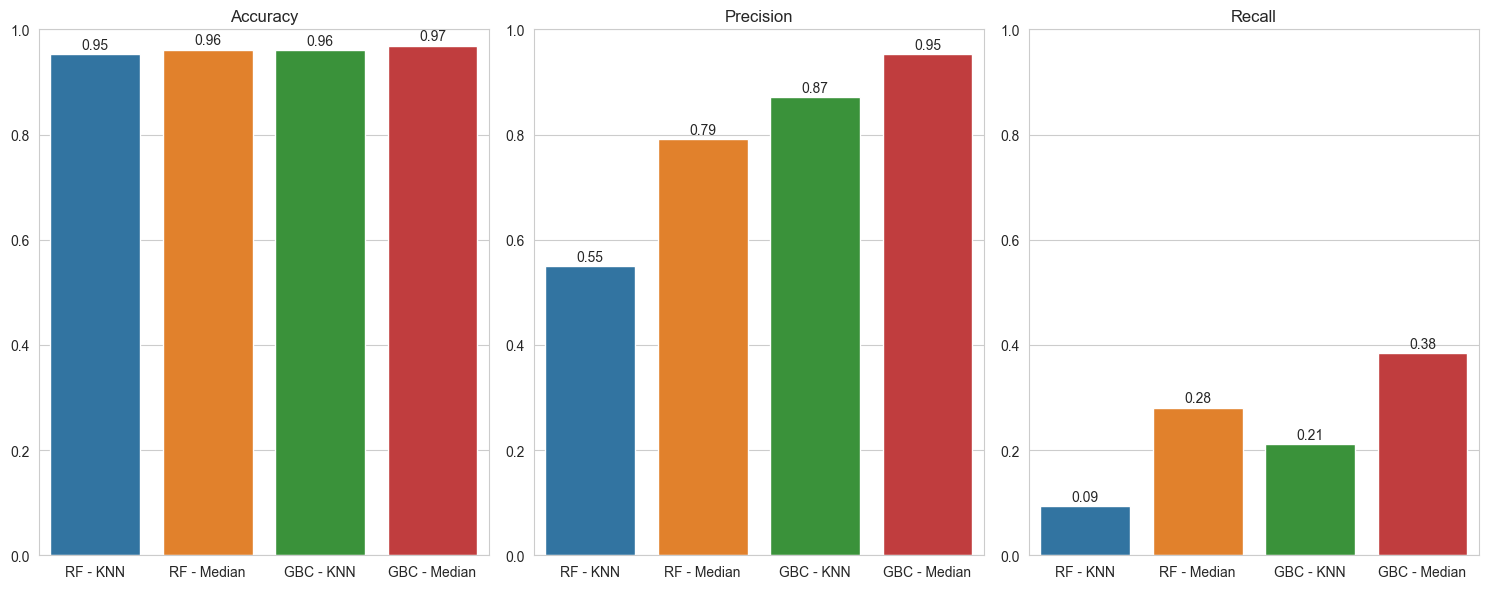

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(15, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
model_names = ["RF - KNN", "RF - Median", "GBC - KNN", "GBC - Median"]
metrics_values = [
    [accuracy_knn_rf, accuracy_median_rf, accuracy_knn, accuracy_median],
    [precision_knn_rf, precision_median_rf, precision_knn, precision_median],
    [recall_knn_rf, recall_median_rf, recall_knn, recall_median]
]
metric_titles = ["Accuracy", "Precision", "Recall"]
for i, (values, title) in enumerate(zip(metrics_values, metric_titles)):
    sns.barplot(x=model_names, y=values, ax=ax[i], palette=colors, hue=model_names)
    ax[i].set_title(title)
    #ax[i].set_ylim(0, max(max(values) * 1.1, 0.12 if title != "Accuracy" else 1.0))
    ax[i].set_xlabel("")
    for j, v in enumerate(values):
        ax[i].text(j, v + 0.01, f"{v:.2f}", ha='center')
ax[0].set_ylim(0, 1)
ax[1].set_ylim(0, 1)
ax[2].set_ylim(0, 1)
plt.tight_layout()

# Pytania pomocnicze

**Na czym polega metoda t-SNE? Jaka jest fundamentalna różnica względem PCA?**

Metoda t-SNE to nieliniowa technika redukcji wymiarowości.

Jak działa t-SNE?
1. Analizujemy podobieństwo między punktami w przestrzeni wielowymiarowej - jak bardzo dany punkt jest bliski innemu. Używamy do tego rozkładu Gaussa.
2. W przestrzeni docelowej, punkty są umieszczane tak, aby zachować te same relacje podobieństw między punktami, ale przy użyciu rozkładu Cauchy'ego.
3. Minimalizujemy różnice między rozkładami prawdopodobieństwa.

Różnice między PCA a t-SNE:
|     Cecha    |      PCA (Principal Component Analysis)      |                      t-SNE                      |
|:------------:|:--------------------------------------------:|:-----------------------------------------------:|
| Typ          | Liniowa metoda redukcji wymiarów             | Nieliniowa, probabilistyczna metoda             |
| Cel          | Zachowanie jak największej wariancji danych  | Zachowanie lokalnych struktur (sąsiedztw)       |
| Rozkład      | Brak jawnego modelowania rozkładów           | Probabilistyczne odwzorowanie odległości        |
| Skalowalność | Bardzo szybkie, nadaje się do dużych danych  | Wolniejsze, skomplikowane obliczeniowo          |
| Użycie       | Wstępna redukcja wymiarów, analiza wariancji | Wizualizacja klas, klastrów, struktur lokalnych |


**Na czym polega standaryzacja danych oraz normalizacja danych? Jakie są różnice pomiędzy tymi metodami?**

Standaryzacja polega na przekształceniu danych tak, aby miały:
- średnią (mean) = 0
- odchylenie standardowe = 1

Wzór:
$$
z = \frac{x - \mu}{\sigma}
$$

Normalizacja polega na przekształceniu danych do określonego zakresu, np. $[0, 1]$. Są różne rodzaje normalizacji.

**GradientBoostingClassifier**

Polega na budowaniu wielu słabych klasyfikatorów (np. drzew decyzyjnych) w sposób sekwencyjny, gdzie każdy kolejny model stara się naprawić błędy poprzednich.

Jak działa?
1. Zaczynamy od prostego modelu (np. małego drzewa).
2. Obliczamy reszty (błędy) tego modelu.
3. Trenujemy kolejny model na tych błędach.
4. Powtarzamy proces wiele razy – każdy kolejny model "uczy się" na tym, czego nie umiał poprzedni.
5. Na końcu wyniki wszystkich modeli są sumowane z wagami.

**RandomForestClassifier**


Tworzy „las” wielu drzew decyzyjnych. Każde drzewo jest trenowane na losowo wybranym podzbiorze danych oraz przy użyciu losowo wybranej części cech przy podejmowaniu decyzji w węzłach.

**Precision & Recall**

Precision = $\frac{TP}{TP + FP}$

Recall = $\frac{TP}{TP + FN}$

TP - True Positive, FP - False Positive, FN - False Negative

True positive, czyli poprawnie sklasyfikowane obserwacje.

False positive, czyli obserwacje, które zostały błędnie sklasyfikowane jako pozytywne.

False negative, czyli obserwacje, które zostały błędnie sklasyfikowane jako negatywne.

walidacje w foldach, leave one out chyba